In [53]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from ipywidgets import interact, IntSlider

In [2]:
df = pd.read_csv("ring2_remove_baseline_outlier.csv")


In [3]:
# import pandas as pd
# df = pd.read_csv("../../5_Data/ring2.csv")
# df.to_parquet("../../5_Data/ring2.parquet")

In [5]:
os.listdir()

['.ipynb_checkpoints',
 'extract_peaks.py',
 'features.py',
 'highpass.py',
 'llxaa.ipynb',
 'output.parquet',
 'peaks.parquet',
 'ring2_remove_baseline_outlier.csv',
 'rri.parquet']

In [6]:
re = pd.read_parquet("output.parquet")

In [7]:
re

,date,time,duration,red,ied,accX,accY,accZ,ied_despiked,ied_clean
0,01-04-2026,22:47:00,0:00:00,16186800,16234168,812,47,1949,16234168.0,-172939.357439
1,01-04-2026,22:47:00,0:00:00,16187639,16238248,812,47,1949,16238248.0,-171034.499170
2,01-04-2026,22:47:00,0:00:00,16188541,16240329,812,47,1949,16240329.0,-168931.729276
3,01-04-2026,22:47:00,0:00:00,16189901,16241725,812,47,1949,16241725.0,-166634.209922
4,01-04-2026,22:47:00,0:00:00,16190749,16243498,812,47,1949,16243498.0,-164146.411032
...,...,...,...,...,...,...,...,...,...,...
1968295,02-04-2026,04:16:12,5:29:12,13508395,13651079,-1621,-159,1562,13651079.0,6355.385361
1968296,02-04-2026,04:16:12,5:29:12,13506294,13648198,-1616,-150,1554,13648198.0,5114.146043
1968297,02-04-2026,04:16:12,5:29:12,13504781,13645853,-1631,-153,1545,13645853.0,3595.190950
1968298,02-04-2026,04:16:12,5:29:12,13503444,13643924,-1618,-133,1552,13643924.0,1898.473527


In [8]:
pp = pd.read_parquet("peaks.parquet")

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

# 假设你的完整结果读入为 pp
# pp = pd.read_parquet("peaks.parquet")

# 提取信号和波峰、波谷布尔掩码
y = -1. * pp['ied_clean'].values  # 注意：这里信号取了反，视觉上的高低点会与原信号相反
is_peak_array = pp['is_peak'].values  
is_valley_array = pp['is_valley'].values  # 新增：提取波谷掩码

@interact(
    start=IntSlider(min=0, max=len(y)-200, step=30, value=0, description='start idx'),
    window=IntSlider(min=200, max=100000, step=100, value=500, description='window')
)
def plot_zoom(start=0, window=500):
    end = min(start + window, len(y))
    
    # 构建当前窗口的时间轴 (s)
    t = np.arange(start, end) / 100.0
    
    # 1. 截取当前窗口的信号
    y_slice = y[start:end]
    
    # 2. 截取波峰，找出对应时间和坐标
    peak_mask_slice = is_peak_array[start:end]
    peak_indices = np.where(peak_mask_slice)[0] 
    t_peaks = t[peak_indices]
    y_peaks = y_slice[peak_indices]

    # 3. 截取波谷，找出对应时间和坐标 (新增)
    valley_mask_slice = is_valley_array[start:end]
    valley_indices = np.where(valley_mask_slice)[0]
    t_valleys = t[valley_indices]
    y_valleys = y_slice[valley_indices]

    plt.rcParams['font.size'] = 18
    fig, ax = plt.subplots(figsize=(18, 7))
    
    # 画基础信号连线
    ax.plot(t, y_slice, 'o-', linewidth=1.5, color='tab:blue', label='IED (Inverted)', markersize=4)
    
    # 画波峰标记 (用红色的大叉号标记)
    ax.plot(t_peaks, y_peaks, 'rx', markersize=12, markeredgewidth=2.5, label='Detected Peaks')

    # 画波谷标记 (用绿色的空心圆圈标记，新增)
    ax.plot(t_valleys, y_valleys, 'go', markersize=10, markeredgewidth=2.5, fillstyle='none', label='Detected Valleys')

    ax.set_xlabel('Time (s)')
    ax.set_ylabel('IED (high-pass inverted)')
    ax.set_title(f'Sample {start}~{end} ({window} samples / {window/100:.1f}s)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=0, description='start idx', max=1968100, step=30), IntSlider(value=500, …

In [10]:
pp.head()

,date,time,duration,red,ied,accX,accY,accZ,ied_despiked,ied_clean,is_peak,peak_value,is_valley,valley_value,rr_interval_ms,vv_interval_ms,branch_phase
0,01-04-2026,22:47:00,0:00:00,16186800,16234168,812,47,1949,16234168.0,-172939.357439,False,NaN,False,NaN,NaN,NaN,unknown
1,01-04-2026,22:47:00,0:00:00,16187639,16238248,812,47,1949,16238248.0,-171034.499170,False,NaN,False,NaN,NaN,NaN,unknown
2,01-04-2026,22:47:00,0:00:00,16188541,16240329,812,47,1949,16240329.0,-168931.729276,False,NaN,False,NaN,NaN,NaN,unknown
3,01-04-2026,22:47:00,0:00:00,16189901,16241725,812,47,1949,16241725.0,-166634.209922,False,NaN,False,NaN,NaN,NaN,unknown
4,01-04-2026,22:47:00,0:00:00,16190749,16243498,812,47,1949,16243498.0,-164146.411032,False,NaN,False,NaN,NaN,NaN,unknown


In [11]:
pp

,date,time,duration,red,ied,accX,accY,accZ,ied_despiked,ied_clean,is_peak,peak_value,is_valley,valley_value,rr_interval_ms,vv_interval_ms,branch_phase
0,01-04-2026,22:47:00,0:00:00,16186800,16234168,812,47,1949,16234168.0,-172939.357439,False,NaN,False,NaN,NaN,NaN,unknown
1,01-04-2026,22:47:00,0:00:00,16187639,16238248,812,47,1949,16238248.0,-171034.499170,False,NaN,False,NaN,NaN,NaN,unknown
2,01-04-2026,22:47:00,0:00:00,16188541,16240329,812,47,1949,16240329.0,-168931.729276,False,NaN,False,NaN,NaN,NaN,unknown
3,01-04-2026,22:47:00,0:00:00,16189901,16241725,812,47,1949,16241725.0,-166634.209922,False,NaN,False,NaN,NaN,NaN,unknown
4,01-04-2026,22:47:00,0:00:00,16190749,16243498,812,47,1949,16243498.0,-164146.411032,False,NaN,False,NaN,NaN,NaN,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1968295,02-04-2026,04:16:12,5:29:12,13508395,13651079,-1621,-159,1562,13651079.0,6355.385361,False,NaN,False,NaN,NaN,NaN,unknown
1968296,02-04-2026,04:16:12,5:29:12,13506294,13648198,-1616,-150,1554,13648198.0,5114.146043,False,NaN,False,NaN,NaN,NaN,unknown
1968297,02-04-2026,04:16:12,5:29:12,13504781,13645853,-1631,-153,1545,13645853.0,3595.190950,False,NaN,False,NaN,NaN,NaN,unknown
1968298,02-04-2026,04:16:12,5:29:12,13503444,13643924,-1618,-133,1552,13643924.0,1898.473527,False,NaN,False,NaN,NaN,NaN,unknown


In [12]:
pd.unique(pp.branch_phase)

<ArrowStringArray>
['unknown', 'descending', 'ascending']
Length: 3, dtype: str

In [13]:
fea = pd.read_parquet("features.parquet")

In [15]:
fea.head(20)

,timestamp,rri_ms,asc_area,desc_area,motion
0,01-04-2026 22:47:01,1100.0,1.337497e+07,3.952694e+07,2097.386514
1,01-04-2026 22:47:02,820.0,1.634264e+07,4.552597e+06,2012.349159
2,01-04-2026 22:47:05,810.0,4.198418e+05,1.570207e+06,1907.738494
3,01-04-2026 22:47:06,780.0,4.591512e+05,1.389924e+06,2200.066015
4,01-04-2026 22:47:06,740.0,2.267045e+05,8.669536e+05,2261.837840
5,01-04-2026 22:47:07,710.0,2.781777e+05,8.090771e+05,2257.098751
6,01-04-2026 22:47:08,740.0,2.602608e+05,9.215927e+05,2231.763019
7,01-04-2026 22:47:09,790.0,2.769366e+05,1.059257e+06,2238.236008
8,01-04-2026 22:47:09,790.0,3.092077e+05,1.144490e+06,2260.750687
9,01-04-2026 22:47:10,800.0,2.664359e+05,1.066004e+06,2235.755126


In [16]:
os.listdir("output")

['all_features.parquet',
 'all_rri.parquet',
 'segments',
 'segment_000_100hz.parquet',
 'segment_000_clean.parquet',
 'segment_000_features.parquet',
 'segment_000_peaks.parquet',
 'segment_000_rri.parquet',
 'segment_001_100hz.parquet',
 'segment_001_clean.parquet',
 'segment_001_features.parquet',
 'segment_001_peaks.parquet',
 'segment_001_rri.parquet',
 'segment_002_100hz.parquet',
 'segment_002_clean.parquet',
 'segment_002_features.parquet',
 'segment_002_peaks.parquet',
 'segment_002_rri.parquet',
 'segment_003_100hz.parquet',
 'segment_003_clean.parquet',
 'segment_003_features.parquet',
 'segment_003_peaks.parquet',
 'segment_003_rri.parquet']

In [17]:
a = pd.read_parquet("./output/all_rri.parquet")
a

,timestamp,rri_ms
0,2026-04-01 22:47:01,NaN
1,2026-04-01 22:47:03,1970.0
2,2026-04-01 22:47:05,790.0
3,2026-04-01 22:47:06,820.0
4,2026-04-01 22:47:07,740.0
...,...,...
12461,2026-04-02 04:16:03,850.0
12462,2026-04-02 04:16:05,820.0
12463,2026-04-02 04:16:06,910.0
12464,2026-04-02 04:16:07,1010.0


In [14]:
b = pd.read_parquet("./output/all_features.parquet")
b

,timestamp,rri_ms,asc_area,desc_area,motion
0,2026-04-01 22:47:03,1970.0,1.129151e+07,1.175838e+07,2030.189278
1,2026-04-01 22:47:05,790.0,3.619852e+06,1.657636e+06,1929.438734
2,2026-04-01 22:47:06,820.0,4.444044e+05,1.557624e+06,2200.066015
3,2026-04-01 22:47:07,740.0,2.222403e+05,9.465404e+05,2261.837840
4,2026-04-01 22:47:07,750.0,2.757732e+05,8.434439e+05,2257.098751
...,...,...,...,...,...
12445,2026-04-02 04:16:02,1020.0,6.435561e+05,1.261994e+06,2248.478099
12446,2026-04-02 04:16:03,850.0,3.537313e+05,1.939107e+06,2249.043721
12447,2026-04-02 04:16:05,820.0,2.160387e+06,9.315351e+05,2244.340149
12448,2026-04-02 04:16:06,910.0,9.337738e+05,1.865255e+06,2248.635773


<Axes: >

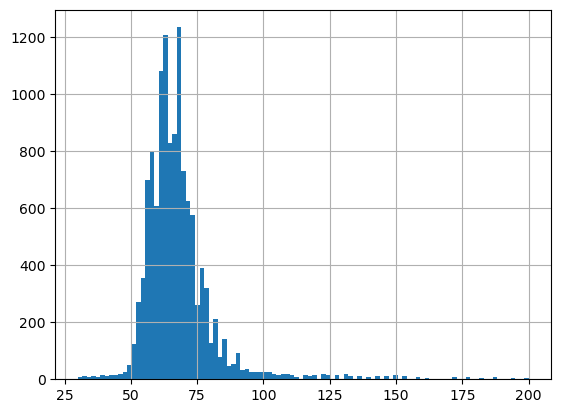

In [15]:
hr = 60000. / b.rri_ms
hr.hist(bins=100)

<Axes: >

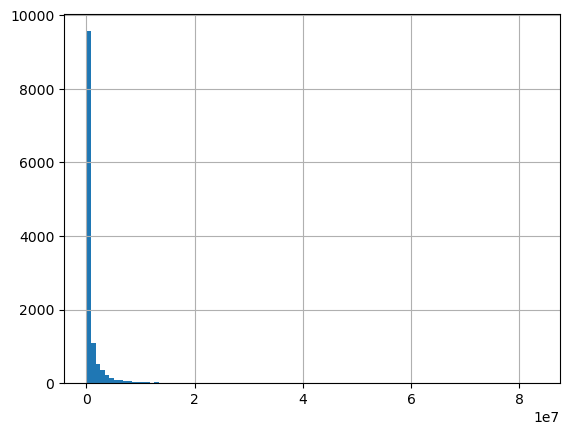

In [16]:
b.asc_area.hist(bins=100)

<Axes: >

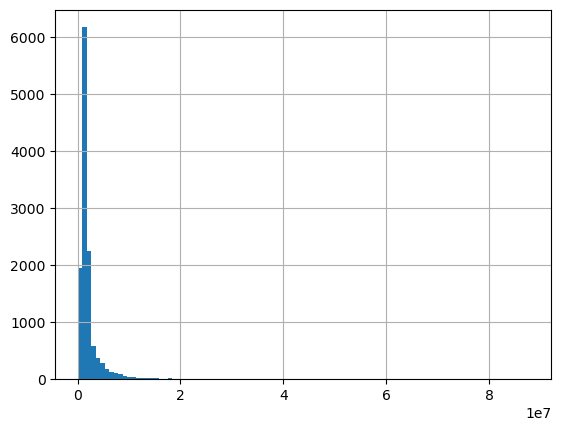

In [17]:
b.desc_area.hist(bins=100)

In [18]:
x = b.desc_area
x[x>0.2e8]

525      6.335015e+07
530      2.752317e+07
1122     3.606353e+07
1462     4.736446e+07
1549     3.378488e+07
             ...     
12192    2.463993e+07
12404    2.108247e+07
12405    3.475203e+07
12407    2.068303e+07
12431    2.711288e+07
Name: desc_area, Length: 80, dtype: float64

In [19]:
y = b.asc_area
y[y > 0.25e8]

533      2.947438e+07
538      3.491314e+07
1287     3.171176e+07
1463     6.263151e+07
1464     3.267579e+07
             ...     
12075    2.772122e+07
12098    4.260024e+07
12113    3.892869e+07
12397    6.323204e+07
12405    4.864529e+07
Name: asc_area, Length: 61, dtype: float64

In [13]:
b.columns

Index(['timestamp', 'rri_ms', 'asc_area', 'desc_area', 'motion'], dtype='str')

In [27]:
y = b.asc_area.to_numpy()


In [33]:
y = np.sort(y)

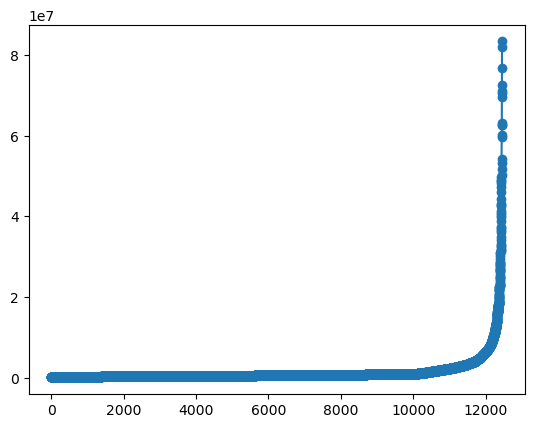

In [34]:

plt.plot(y, 'o-')

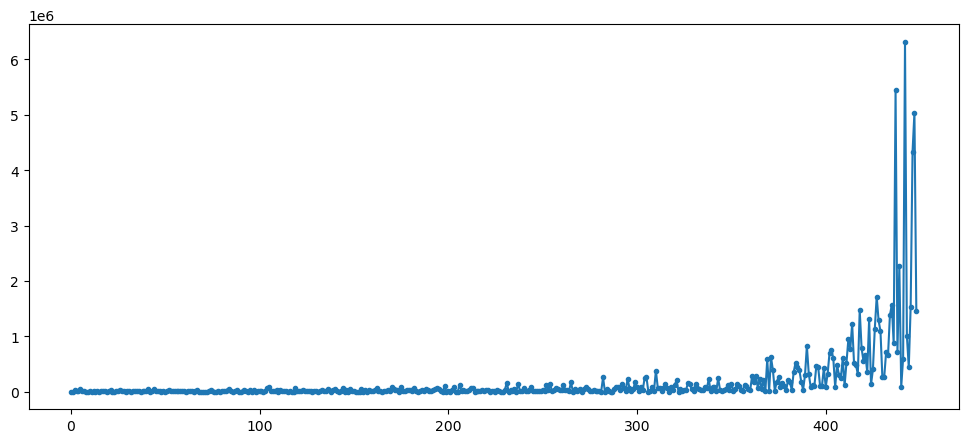

In [39]:
y_ = np.diff(y)
plt.figure(figsize=(12, 5))
plt.plot(y_[12000:], "o-", markersize=3)

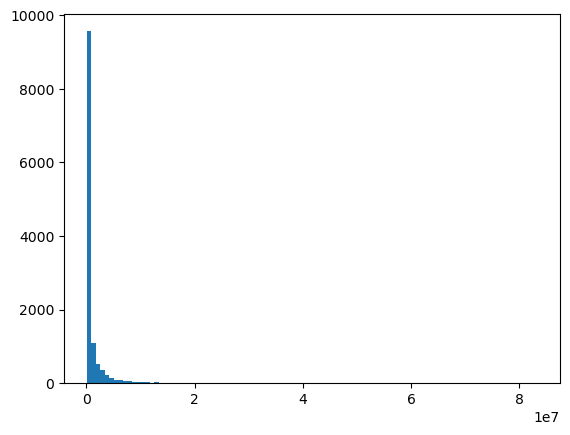

In [41]:
plt.hist(y, bins=100)
plt.show()

临界点（99%分位数）：1.62e+07


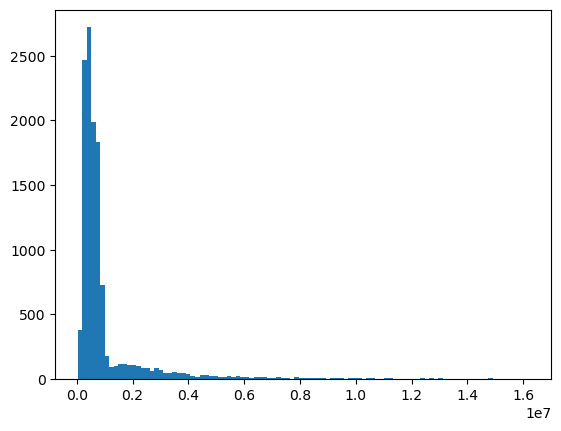

In [52]:

# ===================== 1. 计算临界点（核心步骤）=====================
# 99%分位数：代表99%的正常数据都小于这个值，仅过滤顶部1%的极端异常值
# 可按需调整：异常值极少就用99.5%/99.9%，异常值多就用95%/98%
threshold = np.percentile(y, 99)
print(f"临界点（99%分位数）：{threshold:.2e}")  # 科学计数法输出，方便看数量级

# ===================== 2. 过滤异常值 =====================
y_filtered = y[y <= threshold]

# ===================== 3. 绘制过滤后的直方图 =====================
plt.hist(y_filtered, bins=100)
plt.show()

In [46]:
b

,timestamp,rri_ms,asc_area,desc_area,motion
0,2026-04-01 22:47:03,1970.0,1.129151e+07,1.175838e+07,2030.189278
1,2026-04-01 22:47:05,790.0,3.619852e+06,1.657636e+06,1929.438734
2,2026-04-01 22:47:06,820.0,4.444044e+05,1.557624e+06,2200.066015
3,2026-04-01 22:47:07,740.0,2.222403e+05,9.465404e+05,2261.837840
4,2026-04-01 22:47:07,750.0,2.757732e+05,8.434439e+05,2257.098751
...,...,...,...,...,...
12445,2026-04-02 04:16:02,1020.0,6.435561e+05,1.261994e+06,2248.478099
12446,2026-04-02 04:16:03,850.0,3.537313e+05,1.939107e+06,2249.043721
12447,2026-04-02 04:16:05,820.0,2.160387e+06,9.315351e+05,2244.340149
12448,2026-04-02 04:16:06,910.0,9.337738e+05,1.865255e+06,2248.635773


In [47]:
threshold_asc = b['asc_area'].quantile(0.95)
threshold_desc = b['desc_area'].quantile(0.95)

# 打印阈值，直观查看临界点（科学计数法适配你的大数值场景）
print(f"asc_area 95%分位数阈值：{threshold_asc:.2e}")
print(f"desc_area 95%分位数阈值：{threshold_desc:.2e}")

# ---------------------- 2. 构建「或」关系过滤规则 ----------------------
# 异常行定义：asc_area超阈值 或 desc_area超阈值 → 要去除
# 保留行条件：两列都不超过各自阈值（& 对应 或逻辑的反向）
filter_mask = (b['asc_area'] <= threshold_asc) & (b['desc_area'] <= threshold_desc)

# ---------------------- 3. 生成过滤后的干净DataFrame ----------------------
b_filtered = b[filter_mask].copy()  # 用copy避免SettingWithCopyWarning警告

# 打印过滤前后行数，验证效果
print(f"\n过滤前总行数：{len(b)}")
print(f"过滤后剩余行数：{len(b_filtered)}")
print(f"已去除异常行数：{len(b) - len(b_filtered)}")

asc_area 95%分位数阈值：4.82e+06
desc_area 95%分位数阈值：6.54e+06

过滤前总行数：12450
过滤后剩余行数：11322
已去除异常行数：1128


In [50]:
b_filtered.to_csv("fea_f.csv", index=False)

In [54]:
df = pd.read_csv("da_result.csv")
df

,timestamp,rri_ms,asc_area,desc_area,motion
0,2026-04-01 22:47:05,790.0,3674.0,1728.0,0
1,2026-04-01 22:47:06,820.0,450.0,1400.0,11
2,2026-04-01 22:47:07,740.0,130.0,418.0,13
3,2026-04-01 22:47:08,750.0,190.0,355.0,13
4,2026-04-01 22:47:09,720.0,176.0,373.0,12
...,...,...,...,...,...
86396,2026-04-02 22:47:01,870.0,303.0,4288.0,12
86397,2026-04-02 22:47:02,900.0,570.0,1048.0,12
86398,2026-04-02 22:47:03,990.0,503.0,1044.0,12
86399,2026-04-02 22:47:04,870.0,164.0,419.0,12


In [56]:
import pandas as pd

def encode_dataframe_to_hex(df, output_file='output.txt'):
    """
    将DataFrame中的数据编码为指定的16进制格式并保存到TXT文件中。
    """
    # 确保 timestamp 列是 datetime 对象
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    # 1. 后四列全转为整数 (处理可能存在的NaN为0，确保转换成功)
    cols = ['rri_ms', 'asc_area', 'desc_area', 'motion']
    df[cols] = df[cols].fillna(0).astype(int)
    
    blocks = []
    last_timestamp = None
    current_block = ""
    
    # 2. 逐行处理
    for _, row in df.iterrows():
        # 获取Unix时间戳并转为整数（秒级）
        ts_unix = int(row['timestamp'].timestamp())
        
        # 将各特征转为指定位数的16进制字符串 (使用大写X, 补零)
        # rri_ms: 3位, asc_area: 5位, desc_area: 5位, motion: 4位
        rri_hex = f"{row['rri_ms']:03X}"
        asc_hex = f"{row['asc_area']:05X}"
        desc_hex = f"{row['desc_area']:05X}"
        motion_hex = f"{row['motion']:04X}"
        
        data_str = rri_hex + asc_hex + desc_hex + motion_hex
        
        # 判断时间戳是否改变
        if ts_unix != last_timestamp:
            # 如果不是第一行，先保存上一个时间戳的数据块
            if current_block:
                blocks.append(current_block)
            
            # 时间戳转为8位16进制
            ts_hex = f"{ts_unix:08X}"
            
            # 开启新块：时间戳 + 特征数据
            current_block = ts_hex + data_str
            last_timestamp = ts_unix
        else:
            # 时间戳没变，直接把特征数据接在后面
            current_block += data_str
            
    # 将最后一块追加进去
    if current_block:
        blocks.append(current_block)
        
    # 时间戳不同的块之间用空格连接
    final_output = " ".join(blocks)
    
    # 3. 将全部内容保存在txt文件里
    with open(output_file, 'w', encoding='utf-8') as f:
        f.write(final_output)
        
    print(f"数据已成功转换并保存至: {output_file}")
    return final_output

# ==========================================
# 测试示例：
# 如果您想直接运行此脚本测试，可以解除下面代码的注释
# ==========================================
if __name__ == '__main__':
    # 模拟您的数据
    # data = {
    #     'timestamp': ['2026-04-01 22:47:05', '2026-04-01 22:47:06', '2026-04-01 22:47:07', '2026-04-01 22:47:07', '2026-04-01 22:47:08'],
    #     'rri_ms': [790.0, 820.0, 740.0, 750.0, 720.0],
    #     'asc_area': [3674.0, 450.0, 130.0, 190.0, 176.0],
    #     'desc_area': [1728.0, 1400.0, 418.0, 355.0, 373.0],
    #     'motion': [0, 11, 13, 13, 12]
    # }
    # df = pd.DataFrame(data)

    df = pd.read_csv("da_result.csv")
    encode_dataframe_to_hex(df, 'demo_hex_output.txt')


数据已成功转换并保存至: demo_hex_output.txt
